In [ ]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
df = pd.read_csv(f"{path}/dataset.csv")

display(df.head())

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [11]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df = df.dropna().drop_duplicates(subset=['track_id'])

features = ['danceability', 'energy', 'key', 'loudness', 'mode',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo']

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

In [12]:
X = df_scaled[features].values
modelo = NearestNeighbors(n_neighbors=6, metric='cosine')
modelo.fit(X)

NearestNeighbors(metric='cosine', n_neighbors=6)

In [13]:
def recomendar(musica, df, modelo, features, scaler):
    busca = df[df['track_name'].str.contains(musica, case=False, na=False)]

    if busca.empty:
        return "Música não encontrada."

    idx = busca.index[0]
    nome_ref = busca.iloc[0]['track_name']
    artista_ref = busca.iloc[0]['artists']

    vetor = scaler.transform(df.loc[[idx], features])
    distancias, indices = modelo.kneighbors(vetor, n_neighbors=15)

    print(f"Referência: {nome_ref} - {artista_ref}\n")
    print("Recomendações:")

    contador = 1
    for i in range(1, len(indices[0])):
        rec = df.iloc[indices[0][i]]
        sim = (1 - distancias[0][i]) * 100

        if rec['track_name'].lower() == nome_ref.lower() and rec['artists'].lower() == artista_ref.lower():
            continue

        print(f"{contador}. {rec['track_name']} - {rec['artists']} ({sim:.1f}%)")
        contador += 1

        if contador > 5:
            break

recomendar("Master of Puppets", df, modelo, features, scaler)


Referência: Master Of Puppets - Metallica

Recomendações:
1. Hands Together - Gershon Jackson;Reset Preset (99.7%)
2. I Can´t Stand - Kite (99.7%)
3. Vin Rouge - Felix Da Housecat;Blakk Hazel;Dave The Hustler (99.5%)
4. Freight Train - Vandenberg (99.5%)
5. Dancing Jodi - Salim–Sulaiman (99.4%)


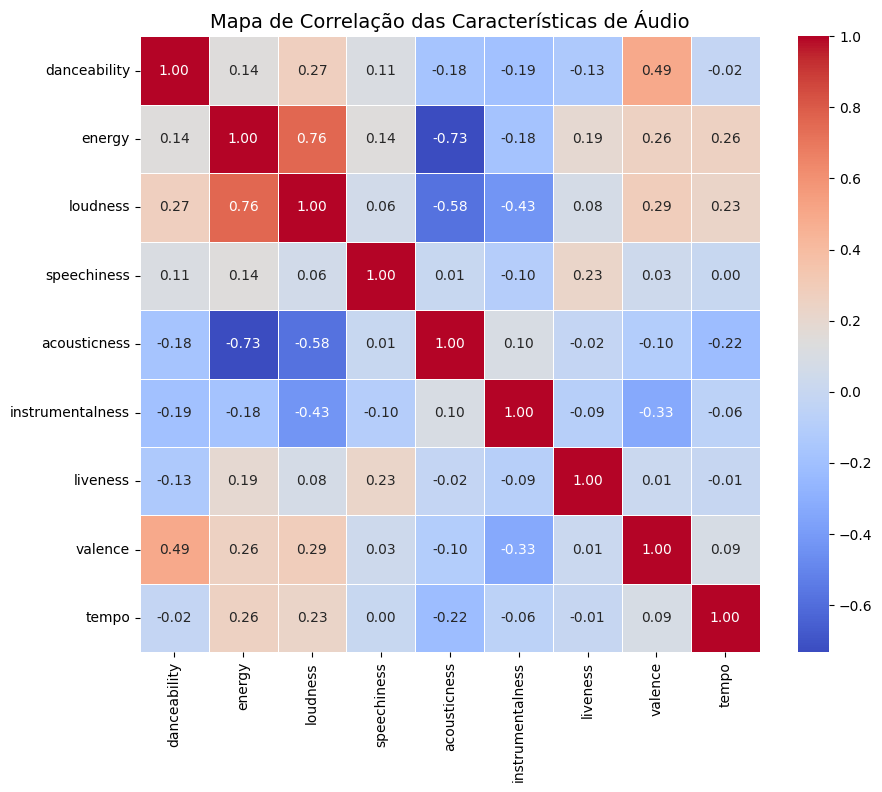

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

features_plot = ['danceability', 'energy', 'loudness', 'speechiness',
                 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

plt.figure(figsize=(10, 8))
sns.heatmap(df[features_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Correlação das Características de Áudio", fontsize=14)
plt.show()



In [15]:
def recomendar_profissional(musica, df, modelo, features, scaler):
    busca = df[df['track_name'].str.contains(musica, case=False, na=False)]

    if busca.empty:
        return "Música não encontrada."

    idx = busca.index[0]
    nome_ref = busca.iloc[0]['track_name']
    artista_ref = busca.iloc[0]['artists']

    vetor = scaler.transform(df.loc[[idx], features])
    distancias, indices = modelo.kneighbors(vetor, n_neighbors=15)

    print(f"Referência: {nome_ref} - {artista_ref} | Gênero: {busca.iloc[0]['track_genre']}\n")

    resultados = []

    for i in range(1, len(indices[0])):
        rec = df.iloc[indices[0][i]]
        sim = (1 - distancias[0][i]) * 100

        if rec['track_name'].lower() == nome_ref.lower() and rec['artists'].lower() == artista_ref.lower():
            continue

        resultados.append({
            'Música': rec['track_name'],
            'Artista': rec['artists'],
            'Gênero': rec['track_genre'],
            'Similaridade (%)': round(sim, 2)
        })

        if len(resultados) == 5:
            break

    df_resultados = pd.DataFrame(resultados)
    df_resultados.index += 1

    return df_resultados

recomendar_profissional("Master of Puppets", df, modelo, features, scaler)


Referência: Master Of Puppets - Metallica | Gênero: hard-rock



,Música,Artista,Gênero,Similaridade (%)
1,Hands Together,Gershon Jackson;Reset Preset,chicago-house,99.72
2,I Can´t Stand,Kite,synth-pop,99.68
3,Vin Rouge,Felix Da Housecat;Blakk Hazel;Dave The Hustler,chicago-house,99.49
4,Freight Train,Vandenberg,hard-rock,99.46
5,Dancing Jodi,Salim–Sulaiman,folk,99.42
